## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import balanced_accuracy_score

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

## Ex 1

### Ex 1.1

Text(0.5, 0.92, 'Original 3D Dataset')

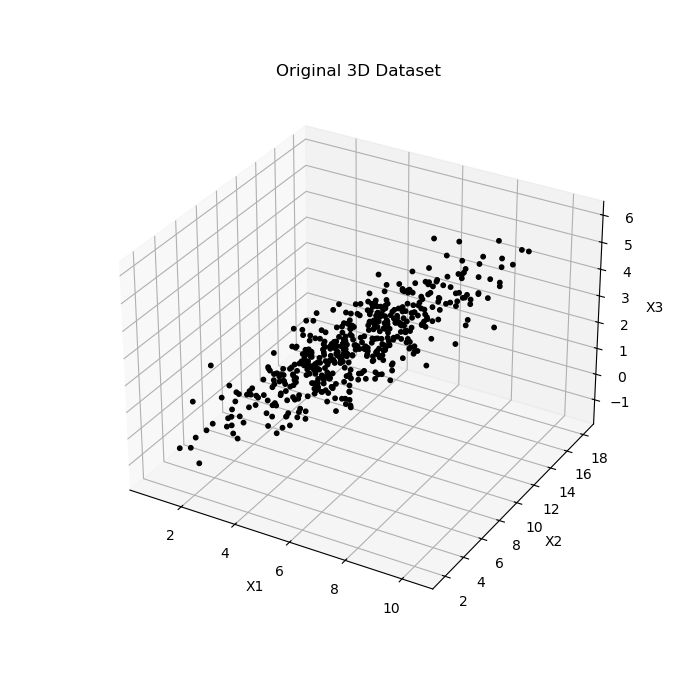

In [3]:
%matplotlib widget

np.random.seed(23)
mean = np.array([5, 10, 2])
cov = np.array([
    [3, 2, 2],
    [2, 10, 1],
    [2, 1, 2]
])

X = np.random.multivariate_normal(mean, cov, size=500)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

plot = ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=10, alpha=1.0, color='black')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Original 3D Dataset')

In [4]:
# center data
X_mean = X.mean(axis=0)
X_centered = X - X_mean

# compute covariance matrix
N = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / N

# eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

### Ex 1.2

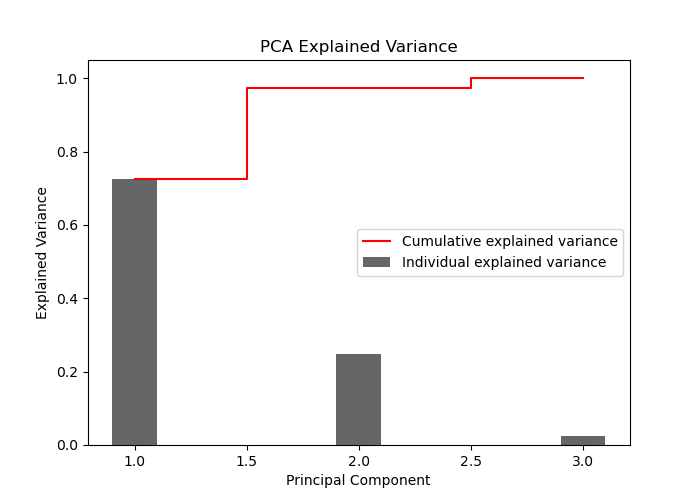

In [5]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(7, 5))

plt.step(range(1, 4), cumulative_variance, where='mid',
         label='Cumulative explained variance', color='red')
plt.bar(range(1, 4), explained_variance,
        alpha=0.6, label='Individual explained variance', width=0.2, color='black')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

### Ex 1.3

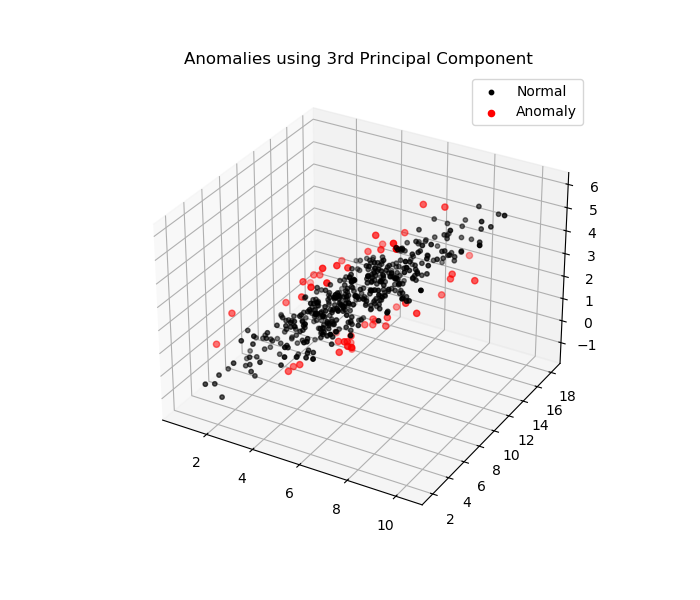

In [6]:
X_pca = X_centered @ eigenvectors
pc3 = X_pca[:, 2]
mean_pc3 = pc3.mean()

deviation_pc3 = np.abs(pc3 - mean_pc3)
threshold_pc3 = np.quantile(deviation_pc3, 0.9)

labels_pc3 = deviation_pc3 > threshold_pc3

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[~labels_pc3, 0], X[~labels_pc3, 1], X[~labels_pc3, 2],
           s=10, label='Normal', color='black')
ax.scatter(X[labels_pc3, 0], X[labels_pc3, 1], X[labels_pc3, 2],
           s=20, c='r', label='Anomaly')

ax.set_title('Anomalies using 3rd Principal Component')
ax.legend()
plt.show()

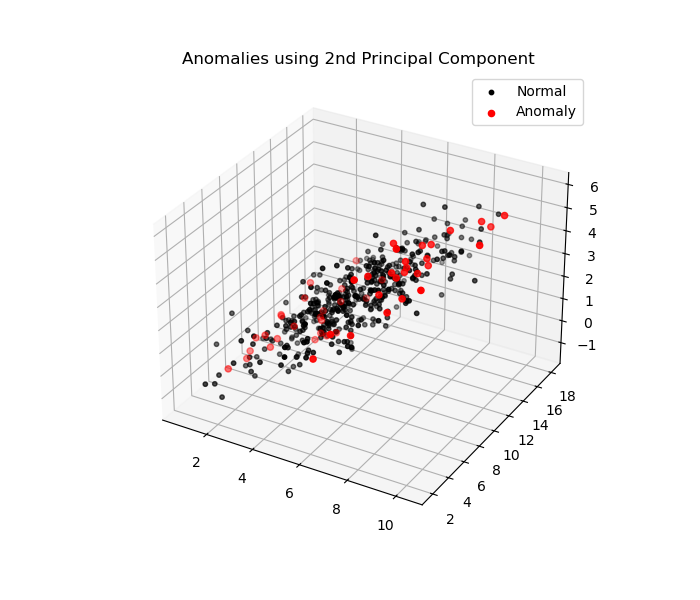

In [7]:
pc2 = X_pca[:, 1]
mean_pc2 = pc2.mean()

deviation_pc2 = np.abs(pc2 - mean_pc2)
threshold_pc2 = np.quantile(deviation_pc2, 0.9)

labels_pc2 = deviation_pc2 > threshold_pc2

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[~labels_pc2, 0], X[~labels_pc2, 1], X[~labels_pc2, 2],
           s=10, label='Normal', color='black')
ax.scatter(X[labels_pc2, 0], X[labels_pc2, 1], X[labels_pc2, 2],
           s=20, c='r', label='Anomaly')

ax.set_title('Anomalies using 2nd Principal Component')
ax.legend()
plt.show()

### Ex 1.4

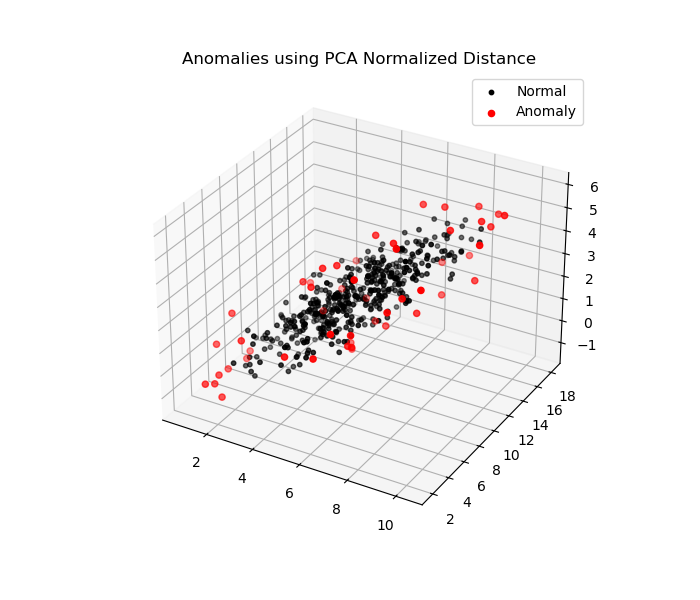

In [8]:
# normalized projections by sqrt of eigenvalues
X_normalized = X_pca / np.sqrt(eigenvalues)

# squared Euclidean distance from centroid
scores = np.sum(X_normalized**2, axis=1)

threshold = np.quantile(scores, 0.9)
labels_dist = scores > threshold

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[~labels_dist, 0], X[~labels_dist, 1], X[~labels_dist, 2],
           s=10, label='Normal', c='black')
ax.scatter(X[labels_dist, 0], X[labels_dist, 1], X[labels_dist, 2],
           s=20, c='r', label='Anomaly')

ax.set_title('Anomalies using PCA Normalized Distance')
ax.legend()
plt.show()


## Ex 2

### Ex 2.1

Original data shape: (49097, 9)
Outlier ratio (pyod, 1 = outlier): 0.0715114976475141

Train shape: (19638, 9)  Test shape: (29459, 9)
Train outlier ratio: 0.07149404216315307
Test  outlier ratio: 0.07152313384704165

Estimated train contamination: 0.07149404216315307


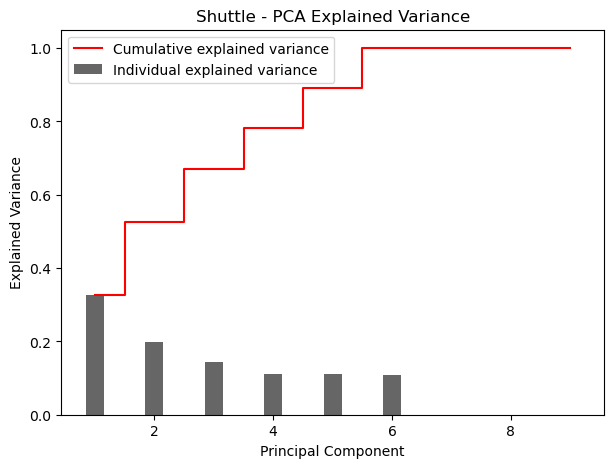

In [ ]:
from pyod.models.pca import PCA

data = loadmat("shuttle.mat")

X = data["X"]
y = data["y"].ravel().astype(int)

print("Original data shape:", X.shape)
print("Outlier ratio (pyod, 1 = outlier):", y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.6,
    random_state=23,
    stratify=y
)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train outlier ratio:", y_train.mean())
print("Test  outlier ratio:", y_test.mean())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_contamination = y_train.mean()
print("\nEstimated train contamination:", train_contamination)

pca = PCA(contamination=train_contamination)
pca.fit(X_train_scaled)

var = pca.explained_variance_
var_ratio = var / np.sum(var)
cum_var = np.cumsum(var_ratio)

plt.figure(figsize=(7, 5))
plt.step(range(1, len(cum_var) + 1), cum_var, where='mid', label='Cumulative explained variance', color='red')
plt.bar(range(1, len(var_ratio) + 1), var_ratio, alpha=0.6, label='Individual explained variance', width=0.3, color='black')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Shuttle - PCA Explained Variance")
plt.legend()
plt.show()


### Ex 2.2

In [ ]:
y_train_pred = pca.predict(X_train_scaled)
y_test_pred  = pca.predict(X_test_scaled)

ba_train = balanced_accuracy_score(y_train, y_train_pred)
ba_test  = balanced_accuracy_score(y_test, y_test_pred)

print("PCA balanced accuracy - train:", ba_train)
print("PCA balanced accuracy - test :", ba_test)


PCA balanced accuracy - train: 0.973535280667561
PCA balanced accuracy - test : 0.9732729784269014


In [ ]:
from pyod.models.kpca import KPCA

kpca = KPCA(contamination=train_contamination)
kpca.fit(X_train_scaled)

y_train_pred = kpca.predict(X_train_scaled)
y_test_pred  = kpca.predict(X_test_scaled)

ba_train = balanced_accuracy_score(y_train, y_train_pred)
ba_test  = balanced_accuracy_score(y_test, y_test_pred)
print("KPCA balanced accuracy - train:", ba_train)
print("KPCA balanced accuracy - test :", ba_test)

KPCA balanced accuracy - train: 0.6291103826888624
KPCA balanced accuracy - test : 0.7717627980132243


## Ex 3

### Ex 3.1

In [ ]:
data = loadmat("shuttle.mat")

X = data["X"]
y = data["y"].ravel().astype(int)

print("Original data shape:", X.shape)
print("Outlier ratio (pyod, 1 = outlier):", y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=23,
    stratify=y
)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train outlier ratio:", y_train.mean())
print("Test  outlier ratio:", y_test.mean())

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_contamination = y_train.mean()
print("\nEstimated train contamination:", train_contamination)

Original data shape: (49097, 9)
Outlier ratio (pyod, 1 = outlier): 0.0715114976475141

Train shape: (24548, 9)  Test shape: (24549, 9)
Train outlier ratio: 0.07149258595404921
Test  outlier ratio: 0.07153040857061388

Estimated train contamination: 0.07149258595404921


### Ex 3.2

In [12]:
class Autoencoder(keras.Model):
    def __init__(self, n_features: int):
        super().__init__()
        self.encoder = keras.Sequential([
            layers.Dense(8, activation="relu"),
            layers.Dense(5, activation="relu"),
            layers.Dense(3, activation="relu"),
        ])
        self.decoder = keras.Sequential([
            layers.Dense(5, activation="relu"),
            layers.Dense(8, activation="relu"),
            layers.Dense(n_features, activation="sigmoid"),
        ])

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

ae = Autoencoder(n_features=X_train_scaled.shape[1])


### Ex 3.3

In [14]:
ae.compile(optimizer="adam", loss="mse")

history = ae.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=1024,
    validation_data=(X_test_scaled, X_test_scaled),
    verbose=1
)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0271 - val_loss: 0.0254
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0247 - val_loss: 0.0234
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0229 - val_loss: 0.0213
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0207 - val_loss: 0.0193
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0188 - val_loss: 0.0175
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0170 - val_loss: 0.0159
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0156 - val_loss: 0.0146
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0142 - val_loss: 0.0134
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0131 - val_loss: 0.0123
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0120 - val_loss: 0.0111
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0108 - val_loss: 0.0100
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

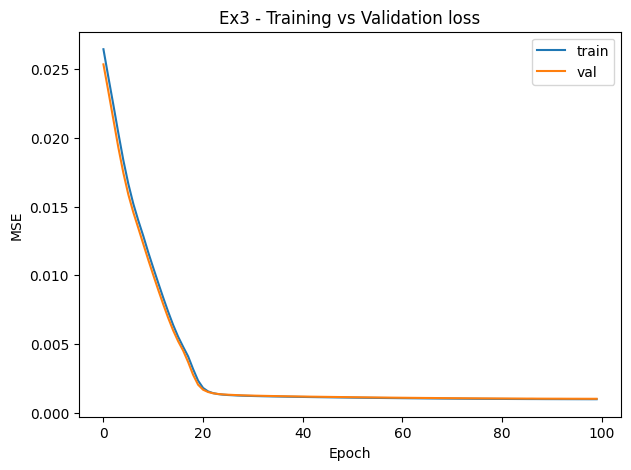

In [15]:
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Ex3 - Training vs Validation loss")
plt.legend()
plt.show()

### Ex 3.4

In [17]:
reconstructed_train = ae.predict(X_train_scaled, batch_size=1024, verbose=0)
reconstructed_test  = ae.predict(X_test_scaled,  batch_size=1024, verbose=0)

train_errors = np.mean(np.square(X_train_scaled - reconstructed_train), axis=1)
test_errors  = np.mean(np.square(X_test_scaled  - reconstructed_test),  axis=1)

thr = np.quantile(train_errors, 1.0 - train_contamination)

y_train_pred = (train_errors > thr).astype(int)
y_test_pred  = (test_errors  > thr).astype(int)

print("Threshold:", thr)
print("BA train:", balanced_accuracy_score(y_train, y_train_pred))
print("BA test :", balanced_accuracy_score(y_test, y_test_pred))

Threshold: 0.002792421297195302
BA train: 0.71126652944755
BA test : 0.7097774568521866


## Ex 4

### Ex 4.1

In [ ]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32") / 255.0)[..., None]

NOISE_FACTOR = 0.35
x_test_noisy = tf.clip_by_value(x_test + tf.random.normal(tf.shape(x_test)) * NOISE_FACTOR, 0.0, 1.0)

print("x_train:", x_train.shape, "x_test:", x_test.shape)

x_train: (60000, 28, 28, 1) x_test: (10000, 28, 28, 1)


### Ex 4.2

In [20]:
class ConvAutoencoder(keras.Model):
    def __init__(self):
        super().__init__()
        self.encoder = keras.Sequential([
            layers.Conv2D(8, (3,3), strides=2, padding="same", activation="relu"),
            layers.Conv2D(4, (3,3), strides=2, padding="same", activation="relu"),
        ])
        self.decoder = keras.Sequential([
            layers.Conv2DTranspose(4, (3,3), strides=2, padding="same", activation="relu"),
            layers.Conv2DTranspose(8, (3,3), strides=2, padding="same", activation="relu"),
            layers.Conv2D(1, (3,3), padding="same", activation="sigmoid"),
        ])

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

cae = ConvAutoencoder()

### Ex 4.3

In [21]:
cae.compile(optimizer="adam", loss="mse")

history_cae = cae.fit(
    x_train, x_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - loss: 0.0732 - val_loss: 0.0060
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 0.0057 - val_loss: 0.0046
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - loss: 0.0046 - val_loss: 0.0040
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - loss: 0.0037 - val_loss: 0.0034
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - loss: 0.0031 - val_loss: 0.0029


In [22]:
recon_train = cae.predict(x_train, batch_size=256, verbose=0)
train_err = np.mean(np.square(x_train - recon_train), axis=(1,2,3))

thr = float(train_err.mean() + train_err.std())
print("Threshold (mean+std):", thr)

Threshold (mean+std): 0.004666622262448072


In [ ]:
recon_test = cae.predict(x_test, batch_size=256, verbose=0)
test_err_clean = np.mean(np.square(x_test - recon_test), axis=(1,2,3))

recon_test_noisy = cae.predict(x_test_noisy, batch_size=256, verbose=0)
test_err_noisy = np.mean(np.square(x_test - recon_test_noisy), axis=(1,2,3))

pred_clean = (test_err_clean > thr).astype(int)  # 1 = anomaly
pred_noisy = (test_err_noisy > thr).astype(int)

acc_clean = np.mean(pred_clean == 0)
acc_noisy = np.mean(pred_noisy == 1)

print("Accuracy ORIGINAL test (normal):", acc_clean)
print("Accuracy NOISY test (anomaly):  ", acc_noisy)

Accuracy ORIGINAL test (normal): 0.8761
Accuracy NOISY test (anomaly):   1.0


### Ex 4.4

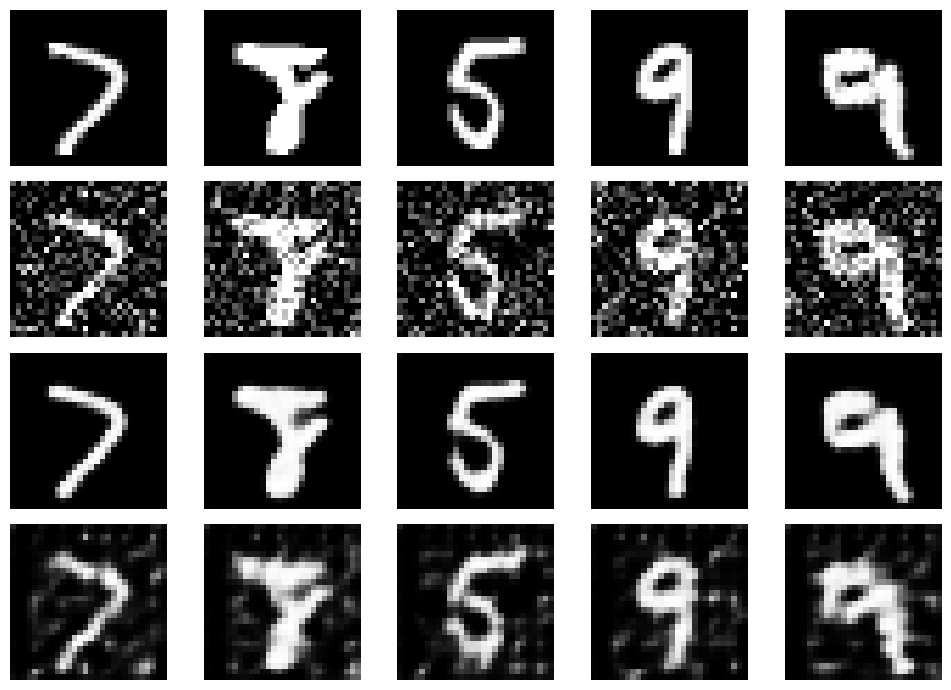

In [24]:
idx = np.random.choice(len(x_test), size=5, replace=False)
orig = x_test[idx]
noisy = tf.clip_by_value(orig + tf.random.normal(tf.shape(orig)) * NOISE_FACTOR, 0.0, 1.0).numpy()

recon_orig = cae.predict(orig, batch_size=5, verbose=0)
recon_noisy = cae.predict(noisy, batch_size=5, verbose=0)

fig, axes = plt.subplots(4, 5, figsize=(10, 7))
for i in range(5):
    axes[0,i].imshow(orig[i].squeeze(), cmap="gray");      axes[0,i].axis("off")
    axes[1,i].imshow(noisy[i].squeeze(), cmap="gray");     axes[1,i].axis("off")
    axes[2,i].imshow(recon_orig[i].squeeze(), cmap="gray");axes[2,i].axis("off")
    axes[3,i].imshow(recon_noisy[i].squeeze(), cmap="gray");axes[3,i].axis("off")

plt.tight_layout()
plt.show()


### Ex 4.5

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 0.0961 - val_loss: 0.0148
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0135 - val_loss: 0.0114
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.0108 - val_loss: 0.0093
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 0.0094 - val_loss: 0.0090
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.0092 - val_loss: 0.0089
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 0.0090 - val_loss: 0.0087
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 0.0088 - val_loss: 0.0086
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.0087 - val_loss: 0.0085
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - loss: 0.0086 - val_loss: 0.0085
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - loss: 0.0085 - val_loss: 0.0083


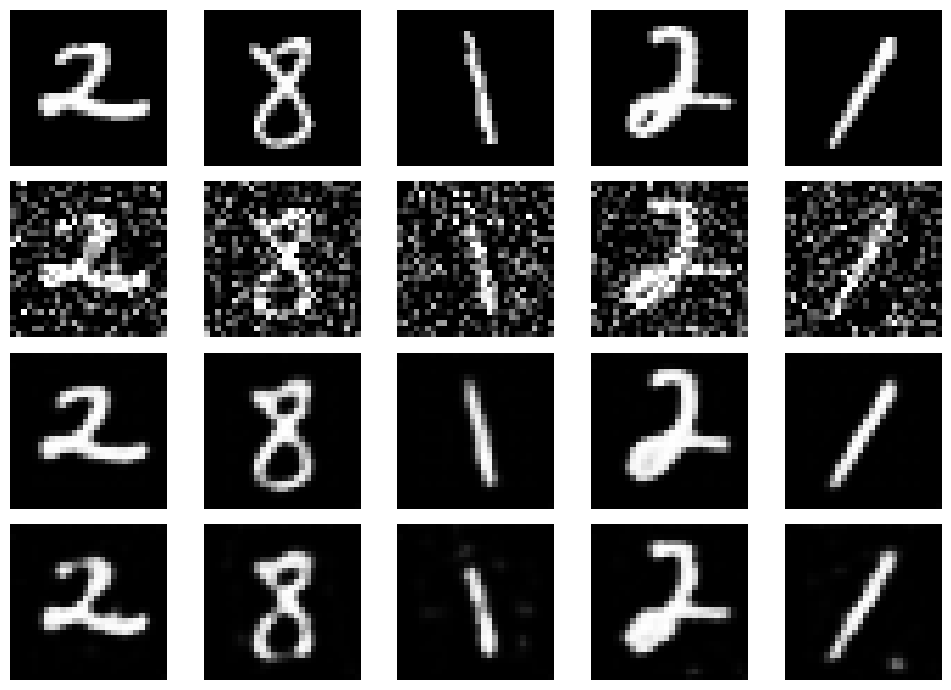

In [ ]:
x_train_noisy = tf.clip_by_value(
    x_train + tf.random.normal(tf.shape(x_train)) * NOISE_FACTOR, 0.0, 1.0
)

dae = ConvAutoencoder()
dae.compile(optimizer="adam", loss="mse")

history_dae = dae.fit(
    x_train_noisy, x_train,   # noisy input -> clean target
    epochs=10,
    batch_size=64,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

idx = np.random.choice(len(x_test), size=5, replace=False)
orig = x_test[idx]
noisy = tf.clip_by_value(orig + tf.random.normal(tf.shape(orig)) * NOISE_FACTOR, 0.0, 1.0).numpy()

recon_orig = dae.predict(orig, batch_size=5, verbose=0)
recon_noisy = dae.predict(noisy, batch_size=5, verbose=0)

fig, axes = plt.subplots(4, 5, figsize=(10, 7))
for i in range(5):
    axes[0,i].imshow(orig[i].squeeze(), cmap="gray");      axes[0,i].axis("off")
    axes[1,i].imshow(noisy[i].squeeze(), cmap="gray");     axes[1,i].axis("off")
    axes[2,i].imshow(recon_orig[i].squeeze(), cmap="gray");axes[2,i].axis("off")
    axes[3,i].imshow(recon_noisy[i].squeeze(), cmap="gray");axes[3,i].axis("off")

plt.tight_layout()
plt.show()